# Level 2 - Task 2: Time Series Analysis (Stock Prices)
**Objective:** Analyze historical stock price data for Apple (AAPL) to identify long-term trends, seasonality, and perform moving average smoothing.

In [2]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# Load the  stock dataset

df = pd.read_csv('2) Stock Prices Data Set.csv')

In [17]:
# Filter for Apple (AAPL) and prepare the date index

aapl_df = df[df['symbol'] == 'AAPL'].copy()
aapl_df['date'] = pd.to_datetime(aapl_df['date'])
aapl_df.set_index('date', inplace=True)
aapl_df = aapl_df.sort_index()

In [18]:
# Focus on the 'close' price for analysis
aapl_series = aapl_df['close']

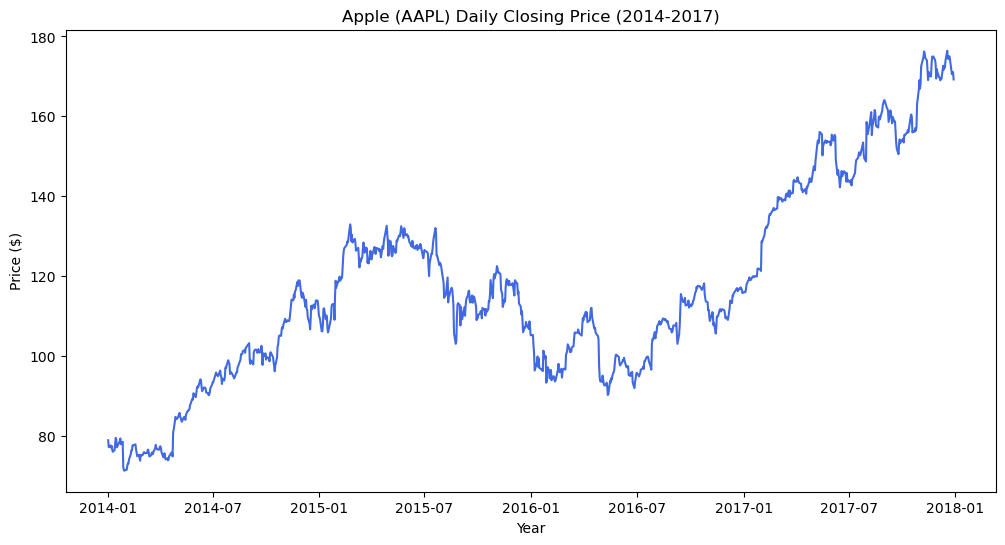

In [19]:
# Initial plot to see the raw data

plt.figure(figsize=(12, 6))
plt.plot(aapl_series, color='royalblue')
plt.title('Apple (AAPL) Daily Closing Price (2014-2017)')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.show()

**Insight:** The initial plot reveals a clear upward trajectory for Apple stock between 2014 and late 2017. However, the raw data is highly volatile, characterized by many short-term "spikes" and "dips," making it difficult to pinpoint exact turning points without further mathematical processing.

### Seasonal Decomposition

In [20]:
# Period=252 represents the approximate number of trading days in a year

decomposition = seasonal_decompose(aapl_series, model='additive', period=252)

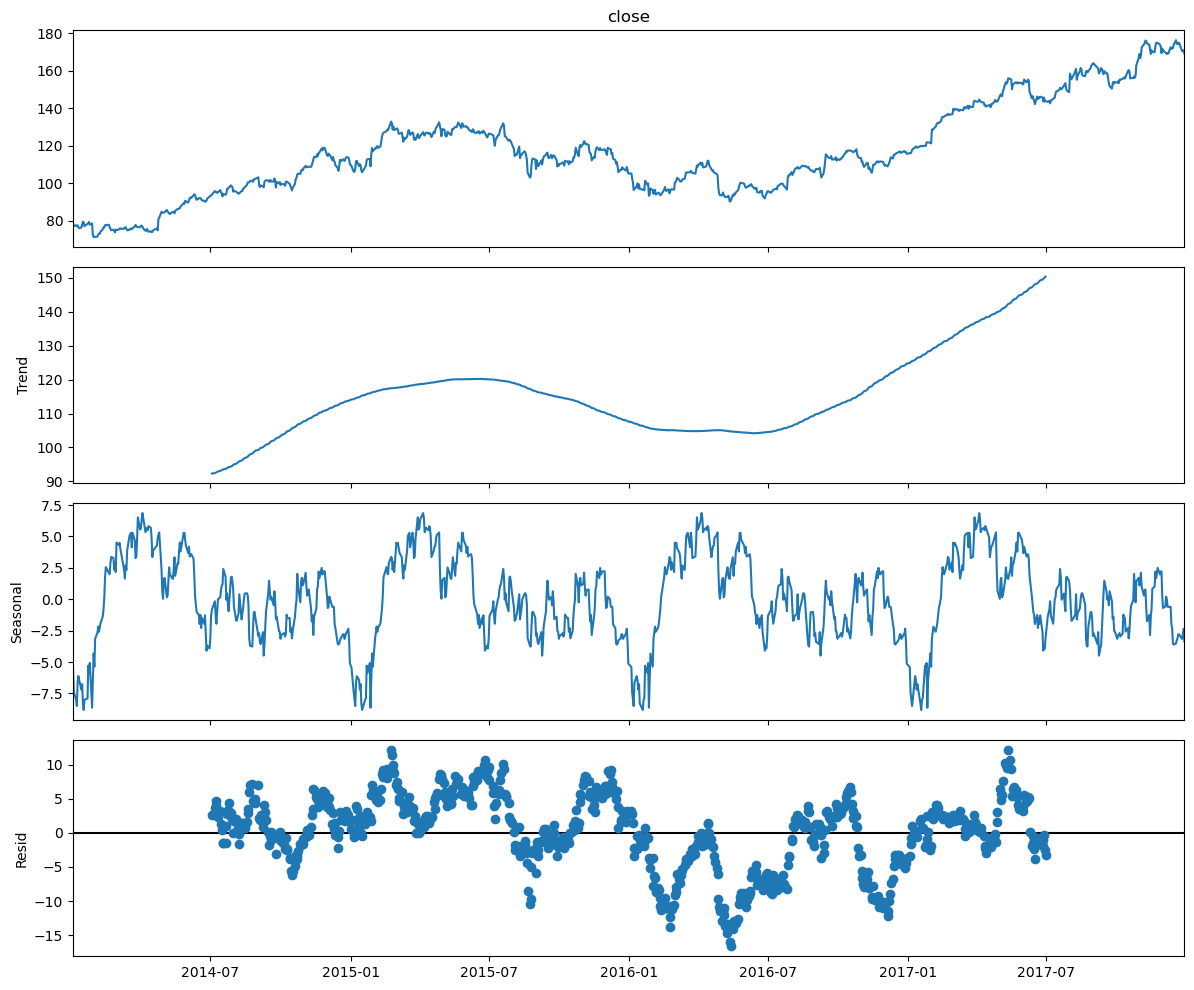

In [21]:
# Plotting the components
plt.rcParams['figure.figsize'] = (12, 10)
decomposition.plot()
plt.show()

**Insight:** By decomposing the data, we separate the "signal" from the "noise."

1.**Trend:** Shows consistent long-term growth, especially a sharp incline starting in 2016.

2.**Seasonality:** Indicates a repeating annual cycle, which often correlates with Apple’s predictable product launch cycles.

3.**Residuals:** Shows random fluctuations that cannot be explained by trend or seasonality, such as unexpected market news.

### Moving Average Smoothing

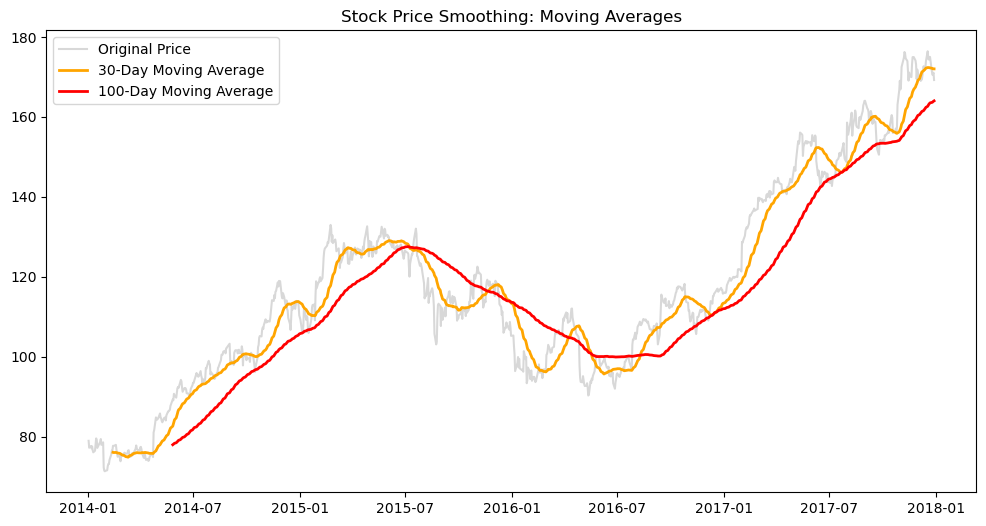

In [22]:
# Calculating 30-day and 100-day moving averages
aapl_30ma = aapl_series.rolling(window=30).mean()
aapl_100ma = aapl_series.rolling(window=100).mean()

plt.figure(figsize=(12, 6))
plt.plot(aapl_series, label='Original Price', alpha=0.3, color='gray')
plt.plot(aapl_30ma, label='30-Day Moving Average', color='orange', linewidth=2)
plt.plot(aapl_100ma, label='100-Day Moving Average', color='red', linewidth=2)
plt.title('Stock Price Smoothing: Moving Averages')
plt.legend()
plt.show()

**Insight:** Applying a Moving Average helps "smooth" the volatility. The 30-day average provides a clearer view of medium-term momentum, while the 100-day average highlights the primary long-term trend. This smoothing technique is vital for technical analysis as it filters out daily market "jitter" to confirm the stock's overall direction.

## Final Analysis Summary
The Time Series Analysis of AAPL stock demonstrates a robust growth pattern over four years. 
- **Trend Discovery:** The underlying trend is bullish, successfully moving from the **70** range in 2014 to over **170** in late 2017.
- **Seasonality:** There is a discernible annual pattern, suggesting that the stock reacts to external factors or internal business cycles consistently each year.
- **Model Success:** Using statsmodels for decomposition and pandas for smoothing provided a clear mathematical foundation to move from raw, volatile data to actionable investment insights.